<a href="https://colab.research.google.com/github/swornim07/AI-and-Machine-Learning/blob/main/Woksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Name: Swornim Shrestha
##ID: 2407724

## Task 1: Improve the CNN Model From Worksheet 5

Repeat the tasks from Worksheet 5, but improve the CNN model using the same fruit dataset.

Tasks:
- check the dataset folders
- check corrupted images
- count class balance
- visualize random images
- use data augmentation
- build a deeper CNN using Batch Normalization and Dropout
- train, evaluate, save the model, and make a classification report

Mounted at /content/drive
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Image Check Summary
Corrupted images removed: 0
Files skipped due to Drive/OS issues: 0

Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


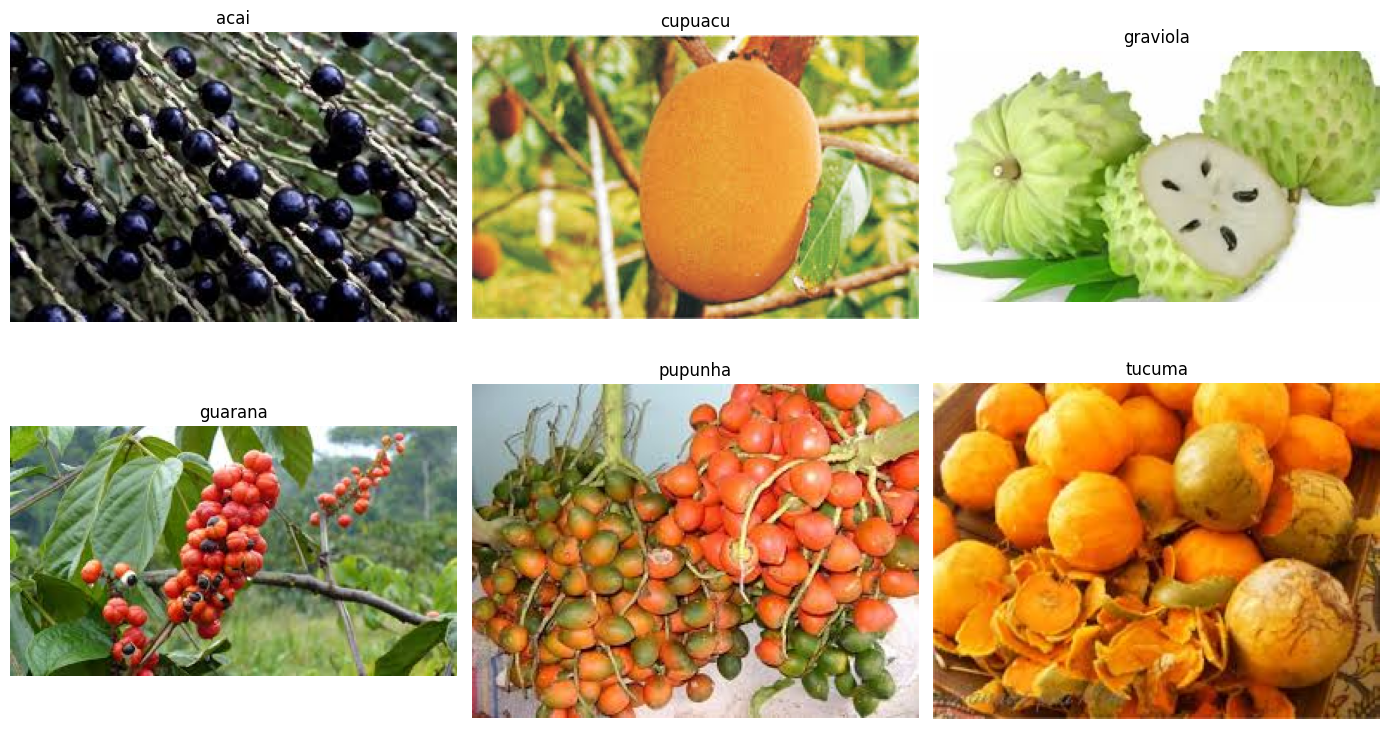

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
project_dir = '/content/drive/MyDrive'
dataset_dir = os.path.join(project_dir, 'FruitinAmazon')
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')

# Valid image extensions
valid_ext = ('.png', '.jpg', '.jpeg')

# Check if train directory exists
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Train directory not found: {train_dir}")

# Get class folders
class_names = sorted([
    name for name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, name))
])

if len(class_names) == 0:
    print('No class directories found in the train folder!')
else:
    print(f'Found {len(class_names)} classes: {class_names}')

# Check for corrupted images safely
corrupted_images = []
skipped_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        # Skip non-image files
        if not img_name.lower().endswith(valid_ext):
            continue

        # Skip if file vanished
        if not os.path.exists(img_path):
            skipped_images.append(img_path)
            print(f'Skipped missing file: {img_path}')
            continue

        try:
            with Image.open(img_path) as img:
                img.load()   # more reliable than verify() for actual reading
        except UnidentifiedImageError:
            corrupted_images.append(img_path)
            print(f'Corrupted image found: {img_path}')

            # delete only if it still exists
            if os.path.exists(img_path):
                os.remove(img_path)
                print(f'Removed corrupted image: {img_path}')

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            print(f'Unreadable image found: {img_path}')

            if os.path.exists(img_path):
                os.remove(img_path)
                print(f'Removed unreadable image: {img_path}')

        except OSError as e:
            # This may be a Google Drive / mount issue, not corruption
            skipped_images.append(img_path)
            print(f'Skipped due to OS/Drive error: {img_path}')
            print(f'  Error: {e}')

print('\nImage Check Summary')
print('=' * 45)
print(f'Corrupted images removed: {len(corrupted_images)}')
print(f'Files skipped due to Drive/OS issues: {len(skipped_images)}')
print('=' * 45)

# Count images in each class
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(valid_ext)
    ]
    class_counts[class_name] = len(images)

print('\nClass Distribution:')
print('=' * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print('=' * 45)
for class_name, count in class_counts.items():
    print(f'{class_name:<25}{count:>15}')
print('=' * 45)

# Show one random image from each class
random.seed(42)
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(valid_ext)
    ]

    if len(images) > 0:
        selected_img = os.path.join(class_path, random.choice(images))
        selected_images.append(selected_img)
        selected_labels.append(class_name)

# Dynamic subplot layout
num_images = len(selected_images)
cols = 3
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(14, 4 * rows))

for i, image_path in enumerate(selected_images):
    plt.subplot(rows, cols, i + 1)

    try:
        with Image.open(image_path) as img:
            plt.imshow(img)
        plt.title(selected_labels[i])
        plt.axis('off')
    except Exception as e:
        plt.text(0.5, 0.5, f'Could not load\n{selected_labels[i]}', ha='center', va='center')
        plt.title(selected_labels[i])
        plt.axis('off')
        print(f'Could not display {image_path}: {e}')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# using 224 by 224 because it also works well for transfer learning later
img_height = 224
img_width = 224
image_size = (img_height, img_width)
batch_size = 16
validation_split = 0.2
seed = 1337

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Class names:', class_names)
print('Number of classes:', num_classes)

for images, labels in train_ds.take(1):
    print('Images shape:', images.shape)
    print('Labels shape:', labels.shape)

# prefetch makes loading a bit faster while training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Images shape: (16, 224, 224, 3)
Labels shape: (16,)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout, Flatten, Dense

# adding augmentation so the model can see slightly changed images during training
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

scratch_model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    # first convolution block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # second convolution block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # third convolution block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # fourth convolution block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# summary helps to understand the layers and parameters
scratch_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2778 - loss: 2.0908
Epoch 1: val_loss improved from None to 1.83393, saving model to /content/drive/MyDrive/week6_best_scratch_cnn.h5



Epoch 1: finished saving model to /content/drive/MyDrive/week6_best_scratch_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2222 - loss: 2.2059 - val_accuracy: 0.1667 - val_loss: 1.8339
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.2535 - loss: 2.0980
Epoch 2: val_loss did not improve from 1.83393
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.2361 - loss: 2.0708 - val_accuracy: 0.0556 - val_loss: 1.8535
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1528 - loss: 2.2659 
Epoch 3: val_loss did not improve from 1.83393
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.1806 - loss: 2.1690 - val_accuracy: 0.0556 - val_loss: 1.9468
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1476 - loss: 2.3212 
Epoch 4: val_loss did not improve from 1.83393
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.1806 - loss: 2.3190 - val_accuracy: 0.0556 - val_loss: 1.9637
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 

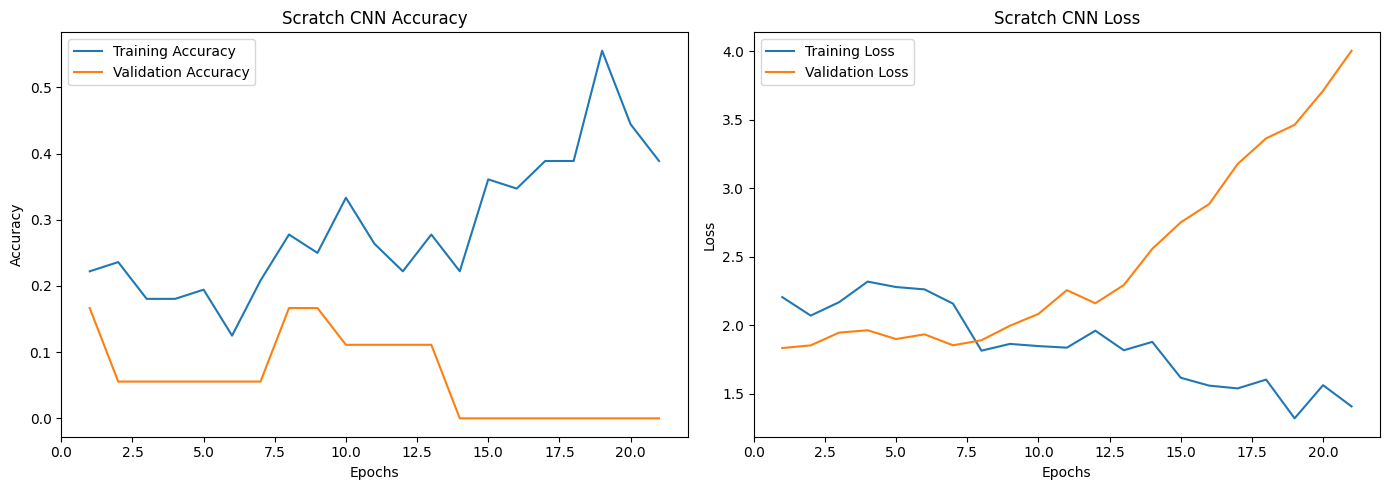

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2000 - loss: 1.7738


Scratch CNN Test Loss: 1.7738
Scratch CNN Test Accuracy: 0.2000
Scratch CNN saved at: /content/drive/MyDrive/week6_scratch_cnn_final.h5
Scratch CNN Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       1.00      0.20      0.33         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.17      1.00      0.29         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.20        30
   macro avg       0.20      0.20      0.10        30
weighted avg       0.20      0.20      0.10        30



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report


scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scratch_best_path = os.path.join(project_dir, 'week6_best_scratch_cnn.h5')
scratch_final_path = os.path.join(project_dir, 'week6_scratch_cnn_final.h5')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=scratch_best_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# training the improved CNN model
scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stop, checkpoint]
)

# plotting accuracy and loss to see training behavior
acc = scratch_history.history['accuracy']
val_acc = scratch_history.history['val_accuracy']
loss = scratch_history.history['loss']
val_loss = scratch_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Scratch CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Scratch CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# evaluating the scratch CNN model
scratch_test_loss, scratch_test_accuracy = scratch_model.evaluate(test_ds)
print(f'Scratch CNN Test Loss: {scratch_test_loss:.4f}')
print(f'Scratch CNN Test Accuracy: {scratch_test_accuracy:.4f}')

scratch_model.save(scratch_final_path)
print(f'Scratch CNN saved at: {scratch_final_path}')

# classification report for scratch CNN
scratch_true_labels = []
scratch_predicted_labels = []

for images, labels in test_ds:
    predictions = scratch_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    scratch_true_labels.extend(labels.numpy())
    scratch_predicted_labels.extend(predicted_classes)

print('Scratch CNN Classification Report:\n')
print(classification_report(scratch_true_labels, scratch_predicted_labels, target_names=class_names, zero_division=0))

## Task 1 Answer: Model Summary and Training Behavior

The improved CNN model used data augmentation, Batch Normalization, and Dropout. The model had 26,257,670 total parameters, with 26,254,790 trainable parameters and 2,880 non-trainable parameters. This shows that the model was much deeper and larger than the previous CNN from Worksheet 5.

From the training result, the model did not perform very well on the test data. The scratch CNN got a test accuracy of 0.2000 and test loss of 1.7738. The validation loss stopped improving after the first epoch, and later the validation accuracy became very low. This means the model was not generalizing properly. Even though Batch Normalization and Dropout were added, the dataset is very small, so the deeper model did not improve the result.


## Task 2: Transfer Learning Using VGG16

Implement transfer learning using a pre-trained model trained on ImageNet weights. Freeze the layers of VGG16 and train only the custom classification layers for the fruits dataset.

Tasks:
- load VGG16 without its top classification layer
- freeze the VGG16 layers
- add my own output layers for the 6 fruit classes
- train the model
- evaluate it and generate inference output
- make a classification report
- compare it with the CNN trained from scratch

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# VGG16 needs its own preprocessing, so I am making separate datasets for it
vgg_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True
)

vgg_val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

vgg_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

# applying the VGG16 preprocessing function
vgg_train_ds = vgg_train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
vgg_val_ds = vgg_val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)
vgg_test_ds = vgg_test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=AUTOTUNE)

# loading VGG16 without the original classifier part
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# freezing the VGG16 layers, so only my new layers train
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=outputs)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1896 - loss: 12.6941   
Epoch 1: val_loss improved from None to 8.17017, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.2083 - loss: 12.2782 - val_accuracy: 0.0000e+00 - val_loss: 8.1702
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2403 - loss: 9.1089
Epoch 2: val_loss improved from 8.17017 to 5.98049, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.2222 - loss: 10.5586 - val_accuracy: 0.1111 - val_loss: 5.9805
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1753 - loss: 10.3553 
Epoch 3: val_loss improved from 5.98049 to 4.31312, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.2361 - loss: 9.5429 - val_accuracy: 0.1667 - val_loss: 4.3131
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3135 - loss: 9.4150
Epoch 4: val_loss improved from 4.31312 to 3.20066, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.2500 - loss: 10.2691 - val_accuracy: 0.4444 - val_loss: 3.2007
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3038 - loss: 7.6604
Epoch 5: val_loss improved from 3.20066 to 2.56216, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5


...


Epoch 34: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 726ms/step - accuracy: 0.7500 - loss: 1.3647 - val_accuracy: 0.8333 - val_loss: 1.4717
Epoch 35/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6715 - loss: 1.9022
Epoch 35: val_loss improved from 1.47168 to 1.47066, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 35: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.6806 - loss: 1.6930 - val_accuracy: 0.8333 - val_loss: 1.4707
Epoch 36/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8323 - loss: 1.1604
Epoch 36: val_loss did not improve from 1.47066
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.7917 - loss: 1.1673 - val_accuracy: 0.8333 - val_loss: 1.4876
Epoch 37/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7438 - loss: 1.2439
Epoch 37: val_loss did not improve from 1.47066
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.7500 - loss: 1.2928 - val_accuracy: 0.8333 - val_loss: 1.4950
Epoch 38/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7767 - loss: 1.3002 
Epoch 38: val_loss did not improve from 1.47066
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.7222 - loss: 1.1941 - val_accuracy: 0.8333 - val_loss: 1.4826
Epoch 39/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/st


Epoch 39: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.7083 - loss: 1.2231 - val_accuracy: 0.8333 - val_loss: 1.4479
Epoch 40/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8708 - loss: 0.4550 
Epoch 40: val_loss improved from 1.44794 to 1.41146, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 40: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.8333 - loss: 0.5827 - val_accuracy: 0.8333 - val_loss: 1.4115
Epoch 41/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7542 - loss: 1.0319
Epoch 41: val_loss improved from 1.41146 to 1.40045, saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5



Epoch 41: finished saving model to /content/drive/MyDrive/week6_best_vgg16_transfer_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.7500 - loss: 1.1714 - val_accuracy: 0.8333 - val_loss: 1.4004
Epoch 42/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6976 - loss: 1.1463
Epoch 42: val_loss did not improve from 1.40045
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.7222 - loss: 1.1061 - val_accuracy: 0.8333 - val_loss: 1.4018
Epoch 43/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5938 - loss: 1.2930 
Epoch 43: val_loss did not improve from 1.40045
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5833 - loss: 1.5237 - val_accuracy: 0.8333 - val_loss: 1.4117
Epoch 44/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7937 - loss: 1.4935
Epoch 44: val_loss did not improve from 1.40045
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8333 - loss: 1.0595 - val_accuracy: 0.8333 - val_loss: 1.4210
Epoch 45/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/s

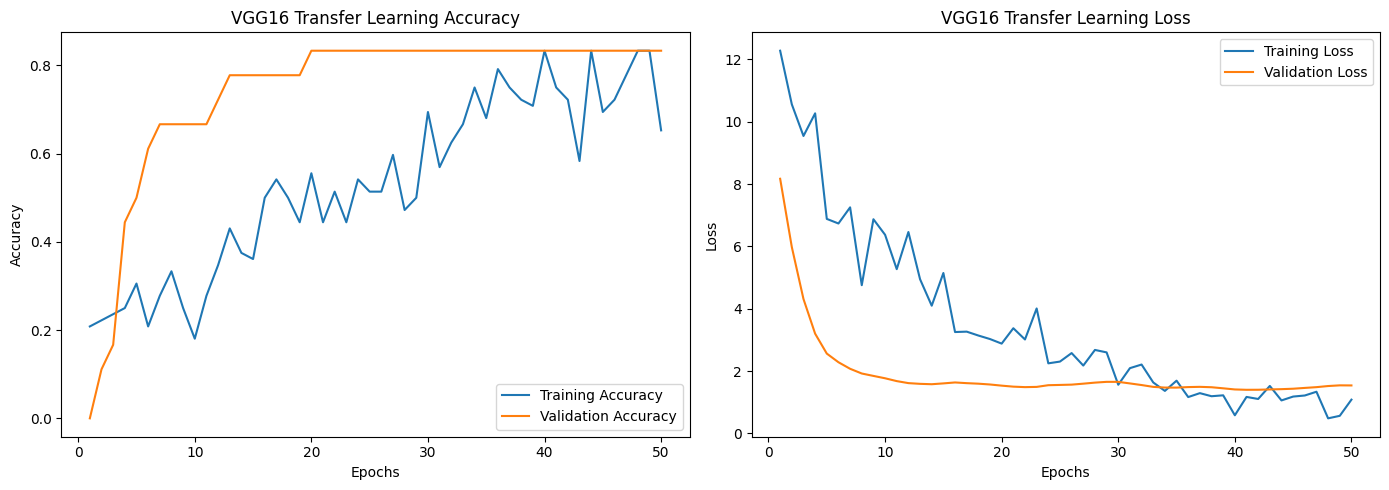

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6667 - loss: 1.9865


VGG16 Test Loss: 1.9865
VGG16 Test Accuracy: 0.6667
VGG16 transfer model saved at: /content/drive/MyDrive/week6_vgg16_transfer_model_final.h5


VGG16 Classification Report:

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.67        30
   macro avg       0.74      0.67      0.64        30
weighted avg       0.74      0.67      0.64        30


Some inference outputs:
Image 1: Predicted = acai, Actual = acai
Image 2: Predicted = acai, Actual = acai
Image 3: Predicted = acai, Actual = acai
Image 4: Predicted = cupuacu, Actual = acai
Image 5: Predicted = acai, Actual = acai
Image 6: Predicted = cupuacu, Actual = cupuacu
Image 7: Predicted = tucuma, Actual = cupuacu
Image 8: Predicted = acai, Actual = cupuacu
Image 9: Predicted = graviola, Actual = cupuacu
Image 10:

In [ ]:
vgg_best_path = os.path.join(project_dir, 'week6_best_vgg16_transfer_model.h5')
vgg_final_path = os.path.join(project_dir, 'week6_vgg16_transfer_model_final.h5')

vgg_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

vgg_checkpoint = ModelCheckpoint(
    filepath=vgg_best_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# training only the custom layers on top of VGG16
vgg_history = vgg_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=50,
    callbacks=[vgg_early_stop, vgg_checkpoint]
)

# plotting training behavior for transfer learning model
vgg_acc = vgg_history.history['accuracy']
vgg_val_acc = vgg_history.history['val_accuracy']
vgg_loss = vgg_history.history['loss']
vgg_val_loss = vgg_history.history['val_loss']
vgg_epochs_range = range(1, len(vgg_acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg_epochs_range, vgg_acc, label='Training Accuracy')
plt.plot(vgg_epochs_range, vgg_val_acc, label='Validation Accuracy')
plt.title('VGG16 Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_epochs_range, vgg_loss, label='Training Loss')
plt.plot(vgg_epochs_range, vgg_val_loss, label='Validation Loss')
plt.title('VGG16 Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# evaluating the transfer learning model
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(vgg_test_ds)
print(f'VGG16 Test Loss: {vgg_test_loss:.4f}')
print(f'VGG16 Test Accuracy: {vgg_test_accuracy:.4f}')

vgg_model.save(vgg_final_path)
print(f'VGG16 transfer model saved at: {vgg_final_path}')

# classification report for VGG16 transfer learning
vgg_true_labels = []
vgg_predicted_labels = []

for images, labels in vgg_test_ds:
    predictions = vgg_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    vgg_true_labels.extend(labels.numpy())
    vgg_predicted_labels.extend(predicted_classes)

print('VGG16 Classification Report:\n')
print(classification_report(vgg_true_labels, vgg_predicted_labels, target_names=class_names, zero_division=0))

# showing inference output for some test images
print('\nSome inference outputs:')
for i in range(min(10, len(vgg_predicted_labels))):
    actual = class_names[int(vgg_true_labels[i])]
    predicted = class_names[int(vgg_predicted_labels[i])]
    print(f'Image {i + 1}: Predicted = {predicted}, Actual = {actual}')

# comparing both models using test accuracy
print('\nModel Accuracy Comparison:')
print(f'Scratch CNN Accuracy: {scratch_test_accuracy:.4f}')
print(f'VGG16 Transfer Learning Accuracy: {vgg_test_accuracy:.4f}')

if vgg_test_accuracy > scratch_test_accuracy:
    print('VGG16 performed better than the CNN trained from scratch.')
elif vgg_test_accuracy < scratch_test_accuracy:
    print('The CNN trained from scratch performed better in this run.')
else:
    print('Both models got the same test accuracy in this run.')

## Task 2 Answer: Did the performance improve compared to training from scratch?

The VGG16-based transfer learning model clearly outperformed the CNN built from scratch in Worksheet 6. The scratch CNN achieved a test accuracy of just 0.2000, whereas the VGG16 model reached 0.6667.

Although the VGG16 model contained 14,879,686 total parameters, only 164,998 were trainable since the pre-trained layers were frozen. This approach was effective because VGG16 had already learned meaningful visual features from the ImageNet dataset. The classification report also indicated improved performance, particularly for categories such as guarana and graviola.

When compared to the CNN from Worksheet 5, the VGG16 model achieved the same overall test accuracy of 0.6667. This suggests that while transfer learning significantly improved performance over the deeper CNN trained from scratch, it did not surpass the results obtained in Worksheet 5 for this experiment.
